# Genome Rewiring – Pearson R Analysis

Evaluate the performance of Ledidi-optimised sequences by comparing the
predicted Hi-C maps to their target maps.

For each sequence pair, Pearson correlation is calculated between the
optimised-sequence prediction and the target Hi-C map.

The notebook reports the Pearson R distribution across all optimised sequences
and saves the resulting histogram as an SVG file.

## Imports and Paths

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr
from torch.utils.data import DataLoader

from utils.model_utils import load_model
from utils.dataset_utils import SequenceDataset, TriuMatrixDataset

## Parameters

In [2]:
FOLD = 0

_PROJ = os.environ["AKITA_SF_DIR"]
BASE_DIR      = f"{_PROJ}/optimizations/genome_rewiring"
MODEL_PATH = os.environ["MOUSE_MODEL_CKPT"]

COORDS_TSV = f"{BASE_DIR}/genomic_optimization_fold{FOLD}.tsv"
OPT_SEQ_DIR = f"{BASE_DIR}/results_fold{FOLD}/"
TARGET_MAP_DIR = f"{_PROJ}/optimizations/genome_rewiring/genomic_targets_fold{FOLD}/"

PLOTS_DIR = os.path.join(os.path.dirname(os.getcwd()), "plots_from_bg")
BATCH_SIZE = 4

os.makedirs(PLOTS_DIR, exist_ok=True)

## Load Model and Data

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = load_model(MODEL_PATH, device)
model.eval()

df = pd.read_csv(COORDS_TSV, sep="\t")
print(f"Loaded {len(df)} sequence pairs")

df_seq = df.copy()
df_seq[["chrom", "start", "end"]] = df[
    ["target_chrom", "target_start", "target_end"]
].values

opt_loader = DataLoader(
    SequenceDataset(df_seq, OPT_SEQ_DIR, suffix="seq"),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

target_loader = DataLoader(
    TriuMatrixDataset(
        df,
        TARGET_MAP_DIR,
        "target_chrom",
        "target_start",
        "target_end",
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Device: cuda:0
Loaded 725 sequence pairs


## Compute Pearson R

In [4]:
pearson_r_list = []

with torch.no_grad():
    for opt_batch, target_batch in zip(opt_loader, target_loader):
        opt_batch = opt_batch.to(device).squeeze(1)       # (B, 4, L)
        target_batch = target_batch.to(device).squeeze(1) # (B, N_triu)

        preds_opt = model(opt_batch).cpu()
        target_batch = target_batch.cpu()

        for pred, target in zip(preds_opt, target_batch):
            r, _ = pearsonr(
                pred.squeeze().numpy(),
                target.squeeze().numpy(),
            )
            pearson_r_list.append(r)

df["pearson_r"] = pearson_r_list

print(
    f"Pearson R — min: {np.min(pearson_r_list):.3f}  "
    f"mean: {np.mean(pearson_r_list):.3f}  "
    f"max: {np.max(pearson_r_list):.3f}"
)

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Pearson R — min: -0.050  mean: 0.959  max: 0.998


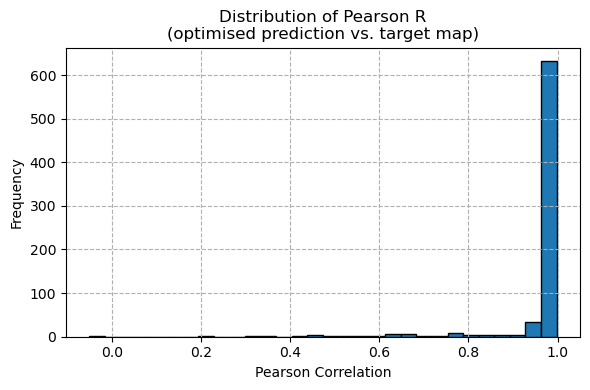

Saved plot to: /home1/smaruj/akita_semifreddo/optimizations/genome_rewiring/plots_from_bg/pearson_r_distribution_bg_fold0.svg


In [5]:
plt.figure(figsize=(6, 4))

plt.hist(
    df["pearson_r"],
    bins=30,
    edgecolor="black",
)

plt.title("Distribution of Pearson R\n(optimised prediction vs. target map)")
plt.xlabel("Pearson Correlation")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--")
plt.tight_layout()

save_path = os.path.join(
    PLOTS_DIR,
    f"pearson_r_distribution_bg_fold{FOLD}.svg",
)

# plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved plot to: {save_path}")